In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print("Visualização das primeiras linhas:")
df.head()

Visualização das primeiras linhas:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# AValiação do desbalanceamento do dataset (~0.17% de transações fraudulentas)
print("Proporção das classes no dataset original:")
print(df['Class'].value_counts(normalize=True))

Proporção das classes no dataset original:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [3]:
# log1p reduz a assimetria na distribuição dos valores das transações
df["Amount_log"] = np.log1p(df[["Amount"]])

In [4]:
from sklearn.preprocessing import StandardScaler

# Normalização com média 0 e desvio padrão 1, necessária para algoritmos sensíveis à escala (ex: Regressão Logística)
scaler = StandardScaler()

df["Amount_log"] = scaler.fit_transform(df[["Amount_log"]])
df["Time_scaled"]= scaler.fit_transform(df[['Time']])

In [5]:
from sklearn.model_selection import train_test_split

x = df.drop(["Class", "Amount", "Time"], axis=1)
y = df["Class"]

# stratify=y é indispensável para preservar a baixa proporção de fraudes nas duas partes
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
    )

In [6]:
from sklearn.linear_model import LogisticRegression

# modelo incial sem tratamento de desbalanceamento para servir de ponto de comparação (Baseline)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [7]:
from sklearn.metrics import classification_report

print("Relatório: Regressão Logística (Baseline)")
print(classification_report(y_test, y_pred))

Relatório: Regressão Logística (Baseline)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



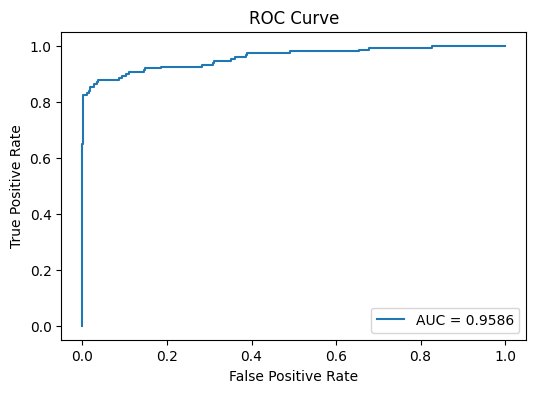

AUC: 0.9585908524152267


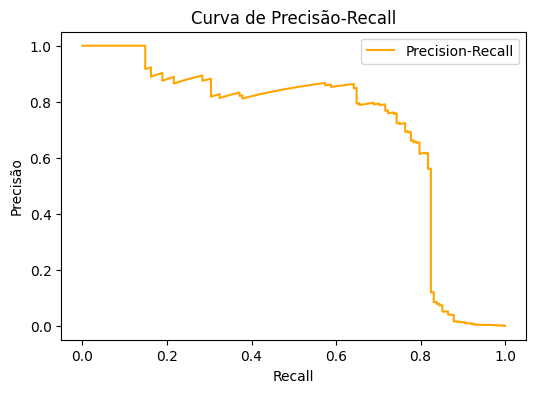

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

# CUrva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label= f"AUC = {roc_auc_score(y_test, y_probs):.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print('AUC:', roc_auc_score(y_test, y_probs))

# a Curva Precisão-Recall reflete melhor a performance real em cenários com desbalancemento severo
prec, rec, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec, color='orange', label='Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva de Precisão-Recall')
plt.legend()
plt.show()

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score

# SMOTE aplicado apenas no treino para evitar data leakage (vazamento de dados de teste)
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x_train, y_train)

model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(x_res, y_res)

y_pred_smote = model_smote.predict(x_test)
recall_smote = recall_score(y_test, y_pred_smote)

print("Relatório: Regressão Logística com SMOTE")
print(classification_report(y_test, y_pred_smote))

Relatório: Regressão Logística com SMOTE
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.86      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.92      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [10]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' ajusta os pesos da função de custo para penalizar mais os erros na classe minoritária
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print('Relatório: Random Forest')
print(classification_report(y_test, y_pred_rf))

Relatório: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.78      0.80       148

    accuracy                           1.00     85443
   macro avg       0.91      0.89      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [11]:
from sklearn.pipeline import Pipeline

# o Pipeline encadeia a padronização e a regressão para garantir que o escalonamento ocorra de forma encapsulada
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

print('Relatório: Pipeline (Scaler + Regressão Logística)')
print(classification_report(y_test, y_pred))

Relatório: Pipeline (Scaler + Regressão Logística)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.62      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [12]:
# redução do limiar de decisão de 0.5 para 0.3 visando aumentar o Recall - captura mais fraudes
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(f"Relatório: Regressão Logística (Threshold = {threshold})")
print(classification_report(y_test, y_pred_custom))

Relatório: Regressão Logística (Threshold = 0.3)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.65      0.71       148

    accuracy                           1.00     85443
   macro avg       0.90      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [13]:
from xgboost import XGBClassifier

# scale_pos_weight equilibra o gradiente da classe positiva durante o boosting sem necessidade de resampling
peso = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(
    scale_pos_weight=peso,
    eval_metric="logloss",
    random_state=42
)


xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
recall_xgb = recall_score(y_test, y_pred_xgb)

print("Regressão: XGBoost Padrão")
print(classification_report(y_test, y_pred_xgb))

print(f'\nComparativo de Recall')
print(f"Recall com SMOTE (Regressão Logística): {recall_smote:.4f}")
print(f"Recall do XGBoost (scale_pos_weight=10): {recall_xgb:.4f}")

Regressão: XGBoost Padrão
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.90      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.95      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443


Comparativo de Recall
Recall com SMOTE (Regressão Logística): 0.8649
Recall do XGBoost (scale_pos_weight=10): 0.7770


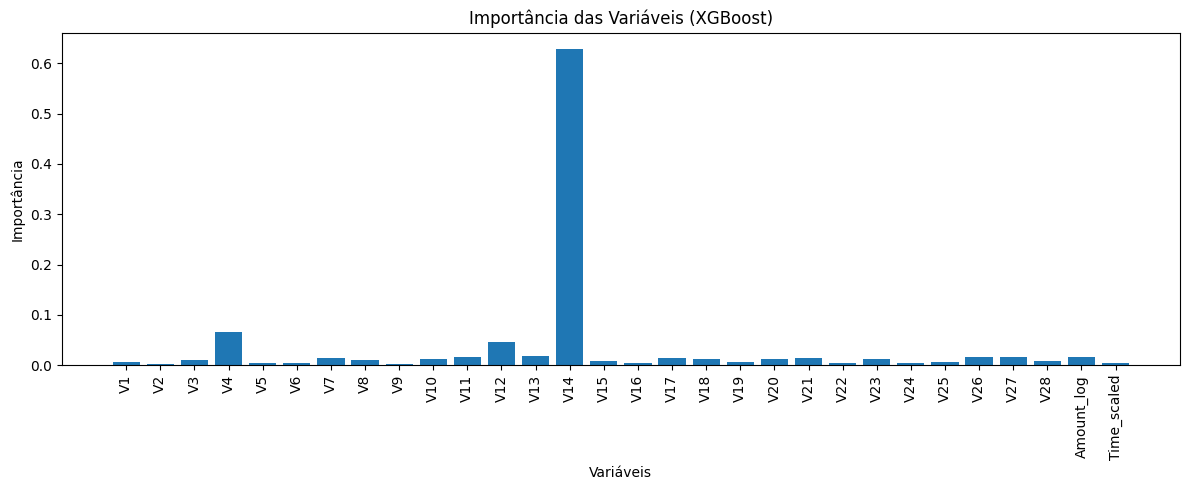

In [14]:
importancias = xgb.feature_importances_

plt.figure(figsize=(12, 5))
# xgb.feature_names_in_ garante os nomes exatos das colunas usadas no treino do modelo
plt.bar(xgb.feature_names_in_, importancias)
plt.xticks(rotation=90)
plt.title("Importância das Variáveis (XGBoost)")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

# scoring='recall' prioriza a busca pelo modelo que minimiza falsos negativos no contexto de fraude
grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid,
    scoring="recall",
    cv=3
)
grid.fit(x_train, y_train)

print("Melhor modelo:", grid.best_params_)

# best_estimator_ retorna o modelo otimizado e já treinado com a totalidade da base de treino
best_xgb = grid.best_estimator_
y_pred_grid = best_xgb.predict(x_test)

print('\nRelatório: XGBoost Otimizado (best_estimator_)')
print(classification_report(y_test, y_pred_grid))

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}

Relatório: XGBoost Otimizado (best_estimator_)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.72      0.78       148

    accuracy                           1.00     85443
   macro avg       0.92      0.86      0.89     85443
weighted avg       1.00      1.00      1.00     85443



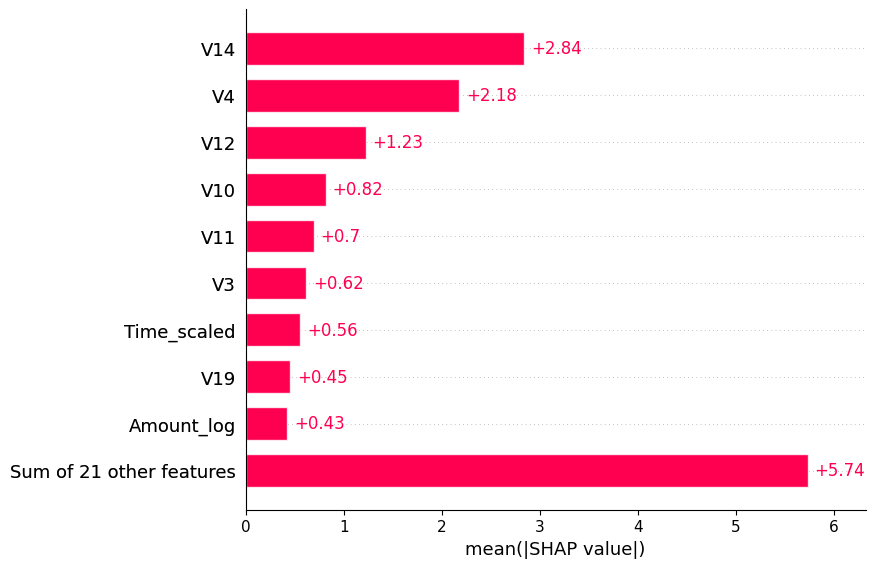

In [16]:
import shap

# cálculo das contribuições marginais (SHAP values) para interpretar as decisões individuais do XGBoost
explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)